# Télécharge votre tranche des comptages routiers permanents de la Ville de Paris.




1. Remplacez ROUTES par vos 3 axes (noms exacts de la colonne `axe` de liste_des_axes.csv).
2. Lancez : python download_data.py
3. Les données arrivent dans data/raw/comptages.csv (dossier ignoré par Git).

Source : https://opendata.paris.fr/explore/dataset/comptages-routiers-permanents/



## Import, Traitement et Analyse des données

In [1]:
from pathlib import Path
import requests
import pandas as pd
import os
from datetime import datetime as dt


In [2]:
ROUTES = ["Lecourbe", "Av_Foch", "Av_Daumesnil"]  # ex. ["Pyrenees", "Av_de_Clichy", "Voie_Mazas"]
DATE_DEBUT = "2026-03-01"
DATE_FIN = "2026-09-01"  # exclue

In [3]:
URL = ("https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/"
       "comptages-routiers-permanents/exports/csv")
COLONNES = ("iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,"
            "iu_nd_aval,libelle_nd_aval,etat_barre")
SORTIE = Path(os.getcwd()) / "data" / "comptages_trafic.csv"

CHEMIN = SORTIE


In [4]:
def main():
    if len(ROUTES) != 3:
        raise SystemExit("Renseignez vos 3 axes dans ROUTES avant de lancer le script.")
    axes = ",".join(f"'{r}'" for r in ROUTES)
    params = {
        "select": COLONNES,
        "where": f"libelle in ({axes}) and t_1h >= date'{DATE_DEBUT}' and t_1h < date'{DATE_FIN}'",
    }
    SORTIE.parent.mkdir(parents=True, exist_ok=True)
    print("Téléchargement en cours (1 à 3 minutes)...")
    with requests.get(URL, params=params, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(SORTIE, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
    taille = SORTIE.stat().st_size / 1e6
    if taille < 0.01:
        raise SystemExit("Fichier vide : vérifiez l'orthographe de vos axes dans ROUTES.")
    print(f"{SORTIE} : {taille:.1f} Mo")

if not SORTIE.exists():  # évite de retélécharger à chaque exécution
    main()

In [5]:
TYPES = {
    "iu_ac": "string", "iu_nd_amont": "string", "iu_nd_aval": "string",
    "libelle": "category", "etat_trafic": "category", "etat_barre": "category",
}

morceaux = []
for i, chunk in enumerate(pd.read_csv(CHEMIN, sep=";", encoding="utf-8-sig",
                                      dtype=TYPES, chunksize=50_000)):
    morceaux.append(chunk)
print(f"{i + 1} chunks lus")

df = pd.concat(morceaux, ignore_index=True)


5 chunks lus


In [6]:
df.shape

(200744, 11)

In [7]:
df.head()

,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre
0,5582,Lecourbe,2026-08-31T23:00:00+00:00,198.0,NaN,Inconnu,2932,Lecourbe-Volontaires,2933,Lecourbe-Cambronne,Ouvert
1,5584,Lecourbe,2026-08-31T23:00:00+00:00,198.0,0.82722,Fluide,2934,Lecourbe-Roussin,2935,Lecourbe-Seche-Peclet,Ouvert
2,4383,Av_Foch,2026-08-31T23:00:00+00:00,145.0,0.40667,Fluide,2351,Foch-Pergolese,2347,Av_Foch-Av_Malakoff,Ouvert
3,4384,Av_Foch,2026-08-31T23:00:00+00:00,464.0,3.03556,Fluide,2351,Foch-Pergolese,2352,Pte_Dauphine-Foch,Ouvert
4,4385,Av_Foch,2026-08-31T23:00:00+00:00,145.0,1.89667,Fluide,2352,Pte_Dauphine-Foch,2351,Foch-Pergolese,Ouvert


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200744 entries, 0 to 200743
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   iu_ac             200744 non-null  string  
 1   libelle           200744 non-null  category
 2   t_1h              200744 non-null  str     
 3   q                 129679 non-null  float64 
 4   k                 137621 non-null  float64 
 5   etat_trafic       200744 non-null  str     
 6   iu_nd_amont       200744 non-null  string  
 7   libelle_nd_amont  200744 non-null  str     
 8   iu_nd_aval        200744 non-null  string  
 9   libelle_nd_aval   200744 non-null  str     
 10  etat_barre        200744 non-null  str     
dtypes: category(1), float64(2), str(5), string(3)
memory usage: 15.5 MB


In [9]:
df.dtypes

iu_ac                 string
libelle             category
t_1h                     str
q                    float64
k                    float64
etat_trafic              str
iu_nd_amont           string
libelle_nd_amont         str
iu_nd_aval            string
libelle_nd_aval          str
etat_barre               str
dtype: object

In [10]:
df.isnull().sum()

iu_ac                   0
libelle                 0
t_1h                    0
q                   71065
k                   63123
etat_trafic             0
iu_nd_amont             0
libelle_nd_amont        0
iu_nd_aval              0
libelle_nd_aval         0
etat_barre              0
dtype: int64

In [11]:
print(f"Il y a {len(df.dropna())} lignes sans valeurs manquantes sur {len(df)} lignes au total. Soit {len(df.dropna()) / len(df) * 100:.1f}% de lignes complètes.")

Il y a 100396 lignes sans valeurs manquantes sur 200744 lignes au total. Soit 50.0% de lignes complètes.


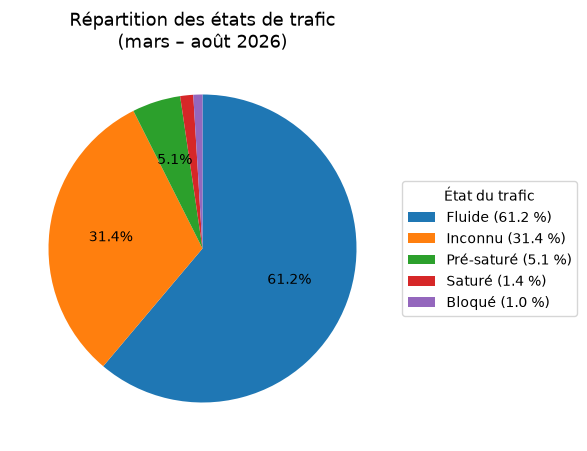

In [12]:
import matplotlib.pyplot as plt

counts = df["etat_trafic"].value_counts()
pct = counts / counts.sum() * 100

ax = counts.plot.pie(
    figsize=(7, 5),
    autopct=lambda p: f"{p:.1f}%" if p >= 5 else "", 
    labels=None,
    ylabel="",
    startangle=90,
    counterclock=False,
)
ax.set_title("Répartition des états de trafic\n(mars – août 2026)", fontsize=13)
ax.legend(
    [f"{etat} ({p:.1f} %)" for etat, p in pct.items()],
    title="État du trafic",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)
plt.show()


**Ce que montre le graphique.** Sur les données brutes, 61,2 % des mesures horaires sont classées « Fluide », contre 5,1 % « Pré-saturé », 1,4 % « Saturé » et 1,0 % « Bloqué ». Mais 31,4 % des lignes sont « Inconnu » : près d'une mesure sur trois n'a pas d'état de trafic exploitable. Cette modalité est examinée dans la partie nettoyage.

libelle
Av_Foch         620.684280
Lecourbe        396.254813
Av_Daumesnil    170.218149
Name: q, dtype: float64


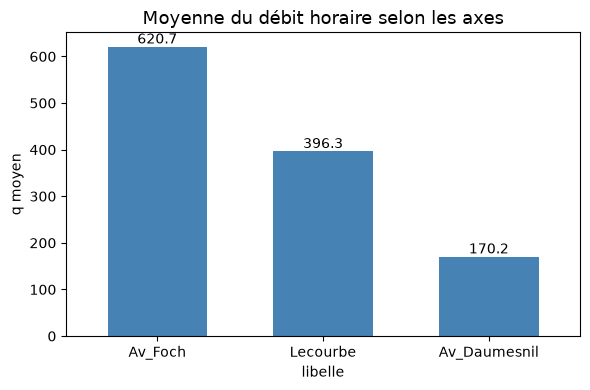

In [13]:
import matplotlib.pyplot as plt

VAR_CAT = "libelle"   # la variable à 3 modalités
VAR_NUM = "q"   # la variable quantitative

moyennes = (
    df.groupby(VAR_CAT, observed=True)[VAR_NUM]
    .mean()
    .sort_values(ascending=False)
)
print(moyennes)

ax = moyennes.plot.bar(figsize=(6, 4), color="steelblue", width=0.6)

ax.set_title(f"Moyenne du débit horaire selon les axes", fontsize=13)
ax.set_xlabel(VAR_CAT)
ax.set_ylabel(f"{VAR_NUM} moyen")
ax.bar_label(ax.containers[0], fmt="%.1f")   # affiche la valeur au-dessus de chaque barre
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Ce que montre le graphique.** L'avenue Foch a le débit horaire moyen le plus élevé (621 véhicules/heure), devant la rue Lecourbe (396) et l'avenue Daumesnil (170). Ces moyennes sont calculées sur les seules lignes où `q` est renseigné, et tous les tronçons d'un axe y pèsent autant : elles donnent un ordre de grandeur par axe, pas le trafic d'un tronçon précis.

# Jalon M2 : Types et nettoyage

### 1. Dates et fuseau horaire

`t_1h` est lue comme du texte. Elle est convertie en date, puis passée de l'UTC à l'heure de Paris : sans cela, toutes les heures seraient décalées de 1 h (hiver) ou 2 h (été), et les heures de pointe seraient mal placées.

In [14]:
df["t_1h"] = pd.to_datetime(df["t_1h"], utc=True)
print(df["t_1h"].dtype)
print(df["t_1h"].min(), "→", df["t_1h"].max())

datetime64[us, UTC]
2026-03-01 00:00:00+00:00 → 2026-08-31 23:00:00+00:00


In [15]:
df["Date_GW"] = df["t_1h"].dt.tz_convert("Europe/Paris")
print(df["Date_GW"].min(), "→", df["Date_GW"].max())

2026-03-01 01:00:00+01:00 → 2026-09-01 01:00:00+02:00


In [16]:
hors_periode = df["Date_GW"] >= pd.Timestamp("2026-09-01", tz="Europe/Paris")
print(f"{hors_periode.sum()} lignes tombent le 1er septembre en heure de Paris")
df = df[~hors_periode].copy()

92 lignes tombent le 1er septembre en heure de Paris


**Choix.** Les dates brutes vont du 1er mars 00:00 au 31 août 23:00 en UTC, soit du 1er mars 01:00 au 1er septembre 01:00 à Paris. Les 92 lignes qui tombent le 1er septembre (2 heures × 46 tronçons) sont supprimées : elles sortent de la période étudiée et formeraient une journée de 2 heures. Il manque en contrepartie l'heure 00:00 du 1er mars.

In [17]:
df["Date"] = df["Date_GW"].dt.date

In [18]:
df["Heure"] = df["Date_GW"].dt.strftime("%H:%M")

In [19]:
noms_mois = {1: "janvier", 2: "février", 3: "mars", 4: "avril", 5: "mai", 6: "juin",
             7: "juillet", 8: "août", 9: "septembre", 10: "octobre", 11: "novembre", 12: "décembre"}

df["Mois"] = df["Date_GW"].dt.month.map(noms_mois)

In [20]:
df["Mois"].value_counts()

Mois
août       34224
juillet    34224
mai        34224
juin       33120
mars       33028
avril      31832
Name: count, dtype: int64

### 2. Types

`etat_trafic` et `etat_barre` étaient déclarées en `category` à la lecture, mais elles sont revenues en texte après l'assemblage des chunks (voir `df.dtypes` plus haut). Elles n'ont que 5 et 3 modalités : elles sont reconverties en `category`. `iu_ac` reste une chaîne, c'est un identifiant et non une quantité.

In [21]:
for col in ["etat_trafic", "etat_barre"]:
    df[col] = df[col].astype("category")
df.dtypes

iu_ac                                     string
libelle                                 category
t_1h                         datetime64[us, UTC]
q                                        float64
k                                        float64
etat_trafic                             category
iu_nd_amont                               string
libelle_nd_amont                             str
iu_nd_aval                                string
libelle_nd_aval                              str
etat_barre                              category
Date_GW             datetime64[us, Europe/Paris]
Date                                      object
Heure                                        str
Mois                                         str
dtype: object

### 3. Doublons

In [22]:
print("Lignes entièrement dupliquées :", df.duplicated().sum())
print("Doublons tronçon + heure :", df.duplicated(subset=["iu_ac", "t_1h"]).sum())

Lignes entièrement dupliquées : 0
Doublons tronçon + heure : 0


In [23]:
heures_attendues = pd.date_range(df["t_1h"].min(), df["t_1h"].max(), freq="h")
print(f"{df['t_1h'].nunique()} heures présentes sur {len(heures_attendues)} attendues")
print("Lignes par tronçon :", df.groupby("iu_ac").size().unique())

4362 heures présentes sur 4414 attendues
Lignes par tronçon : [4362]


**Constat.** Aucune ligne dupliquée, et aucun tronçon n'a deux mesures pour la même heure : il n'y a rien à supprimer. Chaque tronçon a exactement 4 362 lignes, mais la période en compte 4 414 : 52 heures sont absentes pour tous les tronçons à la fois. Ces heures n'existent pas dans la source et ne sont pas recréées.

### 4. Colonnes inutiles

In [24]:
print(df.groupby("iu_ac")[["iu_nd_amont", "iu_nd_aval"]].nunique().max())

noeuds = pd.concat([
    df[["iu_nd_amont", "libelle_nd_amont"]].set_axis(["code", "nom"], axis=1),
    df[["iu_nd_aval", "libelle_nd_aval"]].set_axis(["code", "nom"], axis=1),
]).drop_duplicates()
print(f"{len(noeuds)} couples code/nom, {noeuds['code'].nunique()} codes, {noeuds['nom'].nunique()} noms")

iu_nd_amont    1
iu_nd_aval     1
dtype: int64


33 couples code/nom, 33 codes, 33 noms

In [25]:
df = df.drop(columns=["iu_nd_amont", "iu_nd_aval"])

**Choix.** Chaque tronçon a un seul carrefour amont et un seul carrefour aval, et les 33 codes de carrefour correspondent à 33 noms exactement. Les codes `iu_nd_amont` et `iu_nd_aval` répètent donc l'information des libellés : ils sont supprimés, et les noms sont gardés car ils permettent de situer un tronçon.

### 5. Valeurs manquantes

Les valeurs manquantes sont d'abord croisées avec l'état du tronçon, puis mesurées tronçon par tronçon.

In [26]:
manquant = df["q"].isna() | df["k"].isna()
print(pd.crosstab(df["etat_barre"], manquant, colnames=["q ou k manquant"]))
print()
print(pd.crosstab(df["etat_trafic"], df["k"].isna(), colnames=["k manquant"]))

q ou k manquant   False  True 
etat_barre                    
Barré               331    504
Invalide              0  33593
Ouvert           100011  66213

k manquant    False  True 
etat_trafic               
Bloqué         1921      0
Fluide       122685      0
Inconnu           0  63101
Pré-saturé    10205      0
Saturé         2740      0


In [27]:
df.groupby("etat_barre", observed=True)["q"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
etat_barre,,,,,,,,
Barré,367.0,153.6,340.1,0.0,2.0,24.0,127.0,2179.0
Invalide,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ouvert,129248.0,308.7,257.8,0.0,125.0,226.0,423.0,5518.0


In [28]:
taux_na = (
    df.assign(q_na=df["q"].isna(), k_na=df["k"].isna())
    .groupby(["libelle", "iu_ac"], observed=True)[["q_na", "k_na"]]
    .mean()
    .mul(100)
    .round(1)
)
taux_na

q_na   k_na
libelle      iu_ac              
Av_Daumesnil 4795    86.0    8.2
             4797    13.1    8.2
             4798    13.1   85.5
             4800    13.1    8.2
             4802    86.0    8.2
             4821    57.8   58.0
             4836     1.3    1.3
             4837     1.3    3.5
             4838     1.3    1.3
             4840     1.3    7.2
             4841     1.3    3.5
             4842     0.8    0.9
             4843     8.6    0.8
             4845     0.8    0.8
             4846   100.0    4.0
             5041     0.8    7.7
             5042   100.0  100.0
             5713    86.0   86.0
             5797     8.6   11.8
             5798     0.8   11.6
             5800     0.8   11.6
             5801     8.6   11.8
             905     14.8  100.0
             906     13.1   25.8
Av_Foch      4381     1.4    1.4
             4383     4.9    1.4
             4384     1.4    4.9
             4385     4.9    5.3
             4386   100.0  100.0
             4387   100.0  100.0
             4388    39.8    2.5
             4389    39.8  100.0
             4430    39.8   40.1
             4432   100.0    3.0
             4433    39.8    1.4
             4435   100.0    1.4
Lecourbe     1117   100.0    2.5
             1119   100.0    2.5
             1120   100.0    2.5
             5581     6.2  100.0
             5582     6.2  100.0
             5583     6.2  100.0
             5584     6.2    6.3
             5585     6.2    6.3
             5586     6.2  100.0
             5587   100.0  100.0

**Constats.**

- Les 33 593 lignes `Invalide` ont toutes `q` ou `k` manquant : le capteur signale lui-même que la mesure ne vaut rien.
- Les 835 lignes `Barré` correspondent à une voie fermée : le débit médian y est de 24 véhicules/heure contre 226 quand le tronçon est ouvert.
- « Inconnu » est une valeur manquante déguisée : `etat_trafic` vaut « Inconnu » exactement quand `k` est manquant (63 101 lignes dans les deux cas).
- Les manques ne sont pas répartis au hasard mais concentrés sur certains tronçons : d'après le tableau, 10 tronçons ont 100 % de `q` manquant et 10 ont 100 % de `k` manquant (à 0,1 point près), dont 4 cumulent les deux.

In [29]:
n_avant = len(df)
troncons_avant = df["iu_ac"].nunique()

df = df[df["etat_barre"] == "Ouvert"].drop(columns="etat_barre")
df["etat_trafic"] = df["etat_trafic"].cat.remove_categories("Inconnu")

print(f"{n_avant - len(df)} lignes supprimées, {len(df)} conservées ({len(df) / n_avant * 100:.1f} %)")
print(f"{troncons_avant - df['iu_ac'].nunique()} tronçons sans mesure valide disparaissent, {df['iu_ac'].nunique()} restent")

34428 lignes supprimées, 166224 conservées (82.8 %)
3 tronçons sans mesure valide disparaissent, 43 restent


In [30]:
print(df.shape)
print("Lignes sans q ni k :", (df["q"].isna() & df["k"].isna()).sum())
df.isnull().sum()

(166224, 12)
Lignes sans q ni k : 0


iu_ac                   0
libelle                 0
t_1h                    0
q                   36976
k                   29237
etat_trafic         29237
libelle_nd_amont        0
libelle_nd_aval         0
Date_GW                 0
Date                    0
Heure                   0
Mois                    0
dtype: int64

**Choix.**

- Les lignes `Invalide` et `Barré` sont supprimées (34 428 lignes, 17,2 % du total) : elles ne décrivent pas une circulation normale. `etat_barre` ne contient alors plus que « Ouvert » et la colonne est supprimée. Trois tronçons sans aucune mesure valide disparaissent, il en reste 43.
- « Inconnu » est remplacé par une vraie valeur manquante, pour ne plus être compté comme un état de trafic.
- Les valeurs manquantes restantes (36 976 pour `q`, 29 237 pour `k`) sont conservées telles quelles, sans imputation. Elles viennent surtout de tronçons où une grandeur n'est jamais mesurée : il n'existe aucune valeur voisine sur laquelle s'appuyer, et une moyenne inventerait du trafic. Les lignes sont gardées car il n'en reste aucune sans `q` ni `k` : chacune porte au moins une mesure utilisable.